In [1]:
import numpy as np


In [2]:
data_path = "C:/Users/rdbra/Documents/honoursProject/code_base/Hon_proj_RDB/GRN_work/data/sct_matrix_transposed.npz"    
maindata = np.load(data_path)['arr_0']

top5k_genes_path = "C:/Users/rdbra/Documents/honoursProject/code_base/Hon_proj_RDB/GRN_work/data/sct_top5k.npz"
top5k_genes = np.load(top5k_genes_path)['data']

# print the % of non-zero entries in maindata and top5k_genes
print("Main data non-zero %:", np.count_nonzero(maindata) / maindata.size * 100)
print("Top 5k genes non-zero %:", np.count_nonzero(top5k_genes) / top5k_genes.size * 100)
# Print the % of zero values in each dataset
print("Main data zero %:", (maindata.size - np.count_nonzero(maindata)) / maindata.size * 100)
print("Top 5k genes zero %:", (top5k_genes.size - np.count_nonzero(top5k_genes)) / top5k_genes.size * 100)

Main data non-zero %: 9.72256956157247
Top 5k genes non-zero %: 17.09872842584775
Main data zero %: 90.27743043842753
Top 5k genes zero %: 82.90127157415225


In [3]:
first_gene_main = top5k_genes[0, :]
# Count non-zero entries in the first gene of top5k_genes
non_zero_count = np.count_nonzero(first_gene_main)
total_count = first_gene_main.size
print("First gene non-zero %:", non_zero_count / total_count * 100)

First gene non-zero %: 3.161263720080897


In [5]:
# load the reconstructed file from C:\Users\rdbra\Documents\honoursProject\code_base\Hon_proj_RDB\GRN_work\vqvae2_results\sct_top5k_1000_7_vqvae2_1762730894\vqvae2_recon.npz
recon_path = "C:/Users/rdbra/Documents/honoursProject/code_base/Hon_proj_RDB/GRN_work/vqvae2_results/sct_top5k_1000_7_vqvae2_1762730894/vqvae2_recon.npz"
recon_data = np.load(recon_path)
print(recon_data.files)  # print the keys in the npz file


['reconstructed_matrix']


In [6]:
recon_matrix = recon_data['reconstructed_matrix']  # assuming the key is 'reconstructed'
print("Reconstructed data non-zero %:", np.count_nonzero(recon_matrix) / recon_matrix.size * 100)
print("Reconstructed data zero %:", (recon_matrix.size - np.count_nonzero(recon_matrix)) / recon_matrix.size * 100)  
#print the largest reconstructed value
print("Reconstructed data max value:", recon_matrix.max())
#Get the counts for each bin in the reconstructed data
unique, counts = np.unique(recon_matrix, return_counts=True)   
print(unique)
print(counts)
print("Reconstructed data bin counts:", dict(zip(unique, counts)))

#load sct_top5k_bin.npz to check bins used
sct_top5k_bin_path = "C:/Users/rdbra/Documents/honoursProject/code_base/Hon_proj_RDB/GRN_work/data/sct_top5k_bin.npz"
sct_top5k_bin_data = np.load(sct_top5k_bin_path)   
binned_data = sct_top5k_bin_data[sct_top5k_bin_data.files[0]]
print(sct_top5k_bin_data.files)  # print the keys in the npz file
print(binned_data.max())# print the keys in the npz file

Reconstructed data non-zero %: 5.345707553653125
Reconstructed data zero %: 94.65429244634687
Reconstructed data max value: 3.0
[0. 1. 2. 3.]
[241032423   9736453   2495774   1380350]
Reconstructed data bin counts: {np.float32(0.0): np.int64(241032423), np.float32(1.0): np.int64(9736453), np.float32(2.0): np.int64(2495774), np.float32(3.0): np.int64(1380350)}
['data', 'genes', 'cells']
7.0


# Bin Weight Calculations

In [41]:
def calculate_class_weights(binned_matrix: np.ndarray):
    # calculate the inverse frequency of each bin across the entire matrix
    bins, counts = np.unique(binned_matrix, return_counts=True) 
    print(type(bins[0]), bins)
    total_counts = binned_matrix.size
    class_weights = np.zeros(len(bins), dtype=np.float64)
    for bin_val, count in zip(bins, counts):
        print(f"Bin {bin_val}: Count {count}, Total {total_counts}, Weight {total_counts / (len(bins) * count)}")
        class_weights[int(bin_val)] = total_counts / (len(bins) * count)
    # Normalisation of the weights
    norm_weights = class_weights / np.sum(class_weights)
    return norm_weights
        

In [42]:
print(type(binned_data[0,0]))
bin_weights = calculate_class_weights(binned_data)
print(sum(bin_weights))
print("Bin Weights:", bin_weights)


<class 'numpy.float64'>
<class 'numpy.float64'> [0. 1. 2. 3. 4. 5. 6. 7.]
Bin 0.0: Count 211103943, Total 254645000, Weight 0.1507817644126145
Bin 1.0: Count 38568838, Total 254645000, Weight 0.82529385510655
Bin 2.0: Count 3582761, Total 254645000, Weight 8.884384138378195
Bin 3.0: Count 1252931, Total 254645000, Weight 25.404930518919237
Bin 4.0: Count 97442, Total 254645000, Weight 326.66227088934954
Bin 5.0: Count 31602, Total 254645000, Weight 1007.2345104740207
Bin 6.0: Count 7184, Total 254645000, Weight 4430.766286191537
Bin 7.0: Count 299, Total 254645000, Weight 106456.9397993311
1.0
Bin Weights: [1.34318520e-06 7.35183395e-06 7.91433458e-05 2.26310701e-04
 2.90995354e-03 8.97258694e-03 3.94698904e-02 9.48333420e-01]


In [ ]:
# Calculate the number of entries in recon_matrix that match binned_data and have a value of 0
matching_entries = np.sum((recon_matrix == binned_data) & (binned_data == 0))
zero_assigned_entries = np.sum(binned_data == 0)
print("Total zero entries in reconstructed data:", zero_assigned_entries)
# Calculate how many of the zero assigned entries were assigned correctly
print("Correctly assigned zero entries:", matching_entries)
# Calculate the percentage of correctly assigned zero entries
print("Percentage of correctly assigned zero entries:", (matching_entries / zero_assigned_entries) * 100 if zero_assigned_entries > 0 else 0)
# Calculate the to
total_entries = recon_matrix.size
print("Matching entries between reconstructed and binned data:", matching_entries)
print("Total entries in reconstructed data:", total_entries)
print("Percentage of matching entries:", (matching_entries / total_entries) * 100 if total_entries > 0 else 0)

Total zero entries in reconstructed data: 211103943
Correctly assigned zero entries: 207703574
Percentage of correctly assigned zero entries: 98.3892442027954
Matching entries between reconstructed and binned data: 207703574
Total entries in reconstructed data: 254645000
Percentage of matching entries: 81.56593453631527


Highest expressed gene index: 2797
Highest expressed gene non-zero %: 99.8154293231754
50929


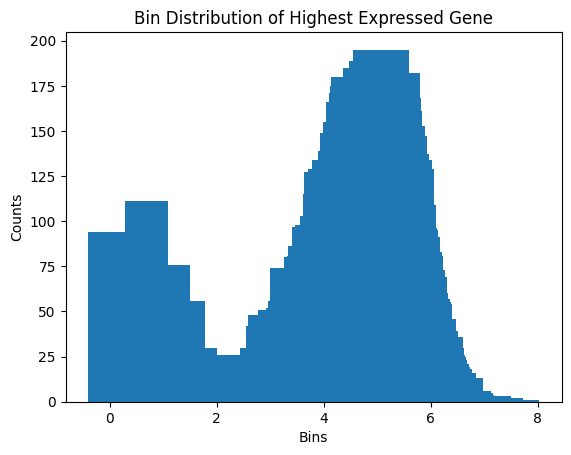

50929


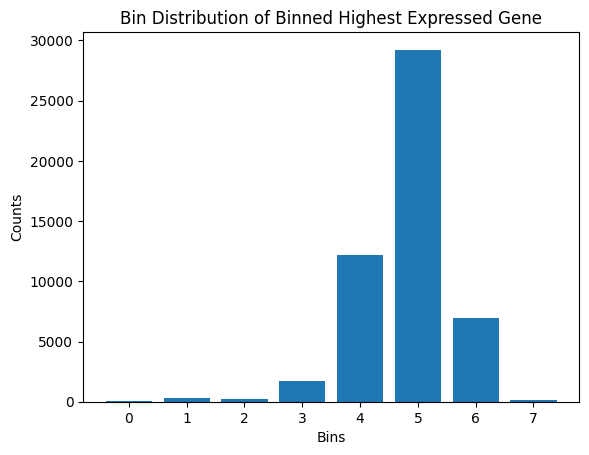

50929


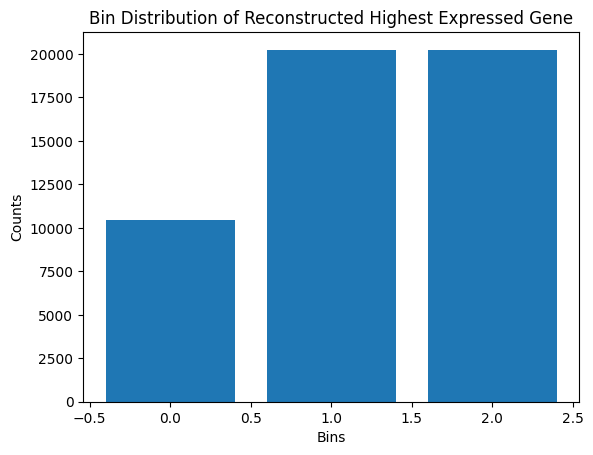

In [14]:
import matplotlib.pyplot as plt
def plot_bin_distribution(data, title):
    import matplotlib.pyplot as plt
    unique, counts = np.unique(data, return_counts=True)
    print(sum(counts))
    plt.bar(unique, counts)
    plt.xlabel('Bins')
    plt.ylabel('Counts')
    plt.title(title)
    plt.show()
#Get the highest expressed gene in the binned top5k genes and plot is distribution from
gene_sums = top5k_genes.sum(axis=1)
highest_expressed_gene_index = np.argmax(gene_sums)
highest_expressed_gene = top5k_genes[highest_expressed_gene_index, :]
print("Highest expressed gene index:", highest_expressed_gene_index)
#Print the non-zero percentage of the highest expressed gene
non_zero_count = np.count_nonzero(highest_expressed_gene) 
total_count = highest_expressed_gene.size
print("Highest expressed gene non-zero %:", non_zero_count / total_count * 100)    
#plot the bin distribution of the highest expressed gene
plot_bin_distribution(highest_expressed_gene, "Bin Distribution of Highest Expressed Gene")
#plot the bin distribution of the reconstructed highest expressed gene 
plot_bin_distribution(binned_data[highest_expressed_gene_index, :], "Bin Distribution of Binned Highest Expressed Gene")
plot_bin_distribution(recon_matrix[highest_expressed_gene_index, :], "Bin Distribution of Reconstructed Highest Expressed Gene") 
#plot the bin distribution of the reconstructed highest expr


Confusion matrix shape: (8, 8)
Total entries counted: 254645000
Overall exact-match (diagonal) count: 215173990 (84.4996%)


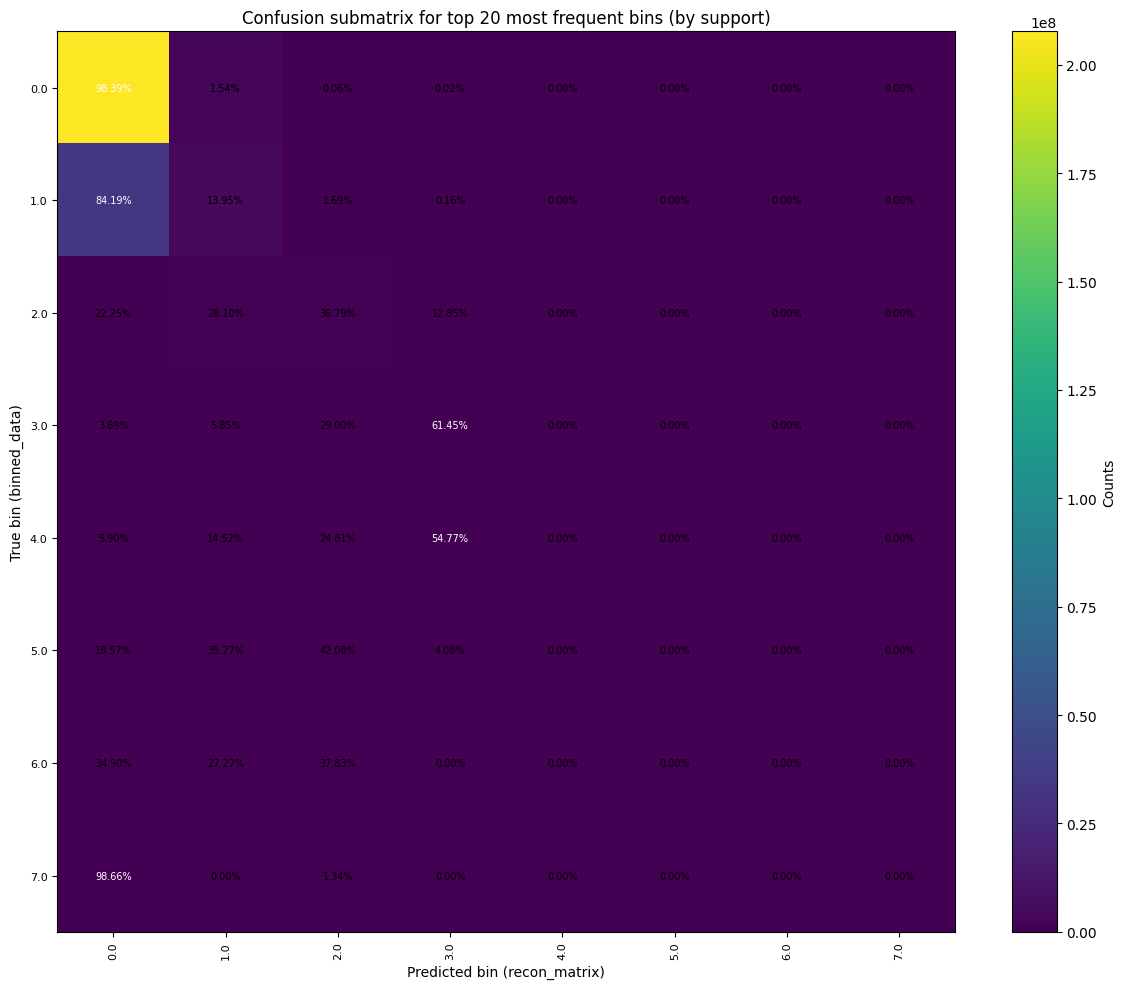

In [19]:
# Compute confusion matrix between true bins (binned_data) and predicted bins (recon_matrix).
# Uses existing variables: binned_data, recon_matrix, plt, np.
true = binned_data.ravel()
pred = recon_matrix.ravel()

# get sorted union of labels
labels = np.unique(np.concatenate((true, pred)))
n_labels = labels.size

# map values to indices (fast via searchsorted since labels is sorted)
true_idx = np.searchsorted(labels, true)
pred_idx = np.searchsorted(labels, pred)

# build confusion matrix via bincount on paired indices
pairs = true_idx * n_labels + pred_idx
conf_flat = np.bincount(pairs, minlength=n_labels * n_labels)
confusion = conf_flat.reshape(n_labels, n_labels).astype(np.int64)

# save full confusion matrix and labels for later analysis
np.savez("confusion_full.npz", confusion=confusion, labels=labels)

# Print summary stats
total = confusion.sum()
correct = np.trace(confusion)
print(f"Confusion matrix shape: {confusion.shape}")
print(f"Total entries counted: {total}")
print(f"Overall exact-match (diagonal) count: {correct} ({correct/total*100:.4f}%)")

# For plotting: annotating every cell for a very large matrix is unreadable.
# Select the top_k true-labels by support (row sums) and plot a smaller annotated submatrix.
top_k = 20
row_support = confusion.sum(axis=1)
top_rows = np.argsort(-row_support)[:top_k]

col_support = confusion.sum(axis=0)
top_cols = np.argsort(-col_support)[:top_k]

sub_conf = confusion[np.ix_(top_rows, top_cols)]
sub_labels_rows = labels[top_rows]
sub_labels_cols = labels[top_cols]

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(sub_conf, aspect='auto', cmap='viridis')
cbar = fig.colorbar(im, ax=ax)
cbar.set_label('Counts')

# ticks and labels
ax.set_xticks(np.arange(len(sub_labels_cols)))
ax.set_yticks(np.arange(len(sub_labels_rows)))
ax.set_xticklabels([str(v) for v in sub_labels_cols], rotation=90, fontsize=8)
ax.set_yticklabels([str(v) for v in sub_labels_rows], fontsize=8)
ax.set_xlabel('Predicted bin (recon_matrix)')
ax.set_ylabel('True bin (binned_data)')
ax.set_title(f'Confusion submatrix for top {top_k} most frequent bins (by support)')

# annotations: show percentage of true-label instances assigned to each predicted label
# percent = (cell count / true-row-support) * 100
row_support_selected = row_support[top_rows].astype(float)
# avoid division by zero
row_support_selected[row_support_selected == 0] = 1.0
percents = (sub_conf.astype(float) / row_support_selected[:, None]) * 100.0
percents_max = percents.max() if percents.size > 0 else 0.0

for i in range(sub_conf.shape[0]):
    for j in range(sub_conf.shape[1]):
        pct = percents[i, j]
        text_color = 'white' if pct > (percents_max / 2.0) else 'black'
        ax.text(j, i, f"{pct:.2f}%", ha='center', va='center', color=text_color, fontsize=7)

plt.tight_layout()
plt.show()

In [22]:
# Create copies of binned_data and recon_matrix to modify for binary accurarcy check
binned_binary = binned_data.copy()
recon_binary = recon_matrix.copy()
# Set all non-zero entries to 1
binned_binary[binned_binary != 0] = 1 
recon_binary[recon_binary != 0] = 1
# Calculate binary accuracy
binary_matching_entries = np.sum(recon_binary == binned_binary)
total_binary_entries = recon_binary.size
print("Binary matching entries between reconstructed and binned data:", binary_matching_entries)
print("Total binary entries in reconstructed data:", total_binary_entries)
print("Percentage of binary matching entries:", (binary_matching_entries / total_binary_entries) * 100 if total_binary_entries > 0 else 0)


Binary matching entries between reconstructed and binned data: 217915782
Total binary entries in reconstructed data: 254645000
Percentage of binary matching entries: 85.5763050521314


C:\Users\rdbra\AppData\Local\Temp\ipykernel_44036\293964464.py:22: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution=0.5)


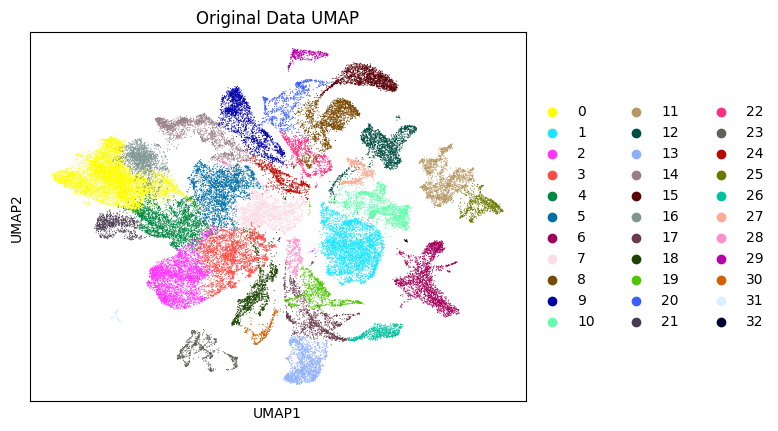

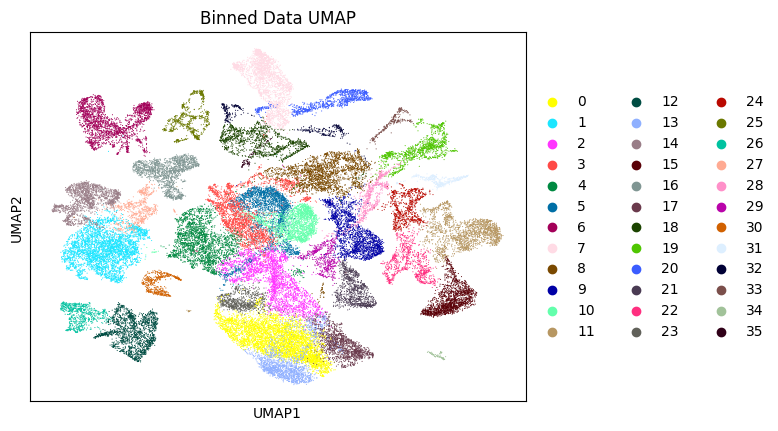

c:\Users\rdbra\Documents\honoursProject\code_base\Hon_proj_RDB\GRN_work\.venv_grn\Lib\site-packages\scanpy\preprocessing\_highly_variable_genes.py:309: RuntimeWarning: invalid value encountered in log
  dispersion = np.log(dispersion)
c:\Users\rdbra\Documents\honoursProject\code_base\Hon_proj_RDB\GRN_work\.venv_grn\Lib\site-packages\legacy_api_wrap\__init__.py:82: UserWarning: `n_top_genes` > number of normalized dispersions, returning all genes with normalized dispersions.
  return fn(*args_all, **kw)
c:\Users\rdbra\Documents\honoursProject\code_base\Hon_proj_RDB\GRN_work\.venv_grn\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


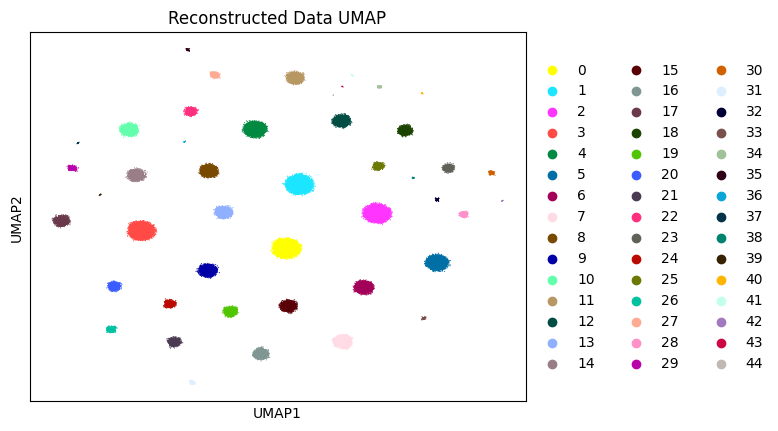

AnnData object with n_obs × n_vars = 50929 × 5000
    obs: 'leiden'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'hvg', 'pca', 'neighbors', 'umap', 'leiden', 'leiden_colors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

In [43]:
import scanpy as sc
import anndata as ad
import igraph
#define function to create anndata object from numpy array
def create_anndata(data, gene_names=None, cell_names=None):
    if gene_names is None:
        gene_names = [f"Gene_{i}" for i in range(data.shape[0])]
    if cell_names is None:
        cell_names = [f"Cell_{i}" for i in range(data.shape[1])]
    adata = ad.AnnData(X=data.T)  # Transpose to have cells as rows
    adata.var_names = gene_names
    adata.obs_names = cell_names
    return adata
#Define function to cluster and plot the UMAP using scanpy 
#include clustering visualisation on the UMAP plot
def cluster_and_plot_umap(adata, title):
    sc.pp.highly_variable_genes(adata, n_top_genes=2000, subset=True)
    sc.pp.scale(adata, max_value=10)
    sc.tl.pca(adata, svd_solver='arpack')
    sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)
    sc.tl.umap(adata)
    sc.tl.leiden(adata, resolution=0.5)
    sc.pl.umap(adata, color=['leiden'], title=title, show=True)
    return adata
# Create anndata objects
adata_original = create_anndata(top5k_genes, gene_names=[f"Gene_{i}" for i in range(top5k_genes.shape[0])])
adata_binned = create_anndata(binned_data, gene_names=[f"Gene_{i}" for i in range(binned_data.shape[0])])
adata_reconstructed = create_anndata(recon_matrix, gene_names=[f"Gene_{i}" for i in range(recon_matrix.shape[0])])
# Cluster and plot UMAPs   
cluster_and_plot_umap(adata_original, "Original Data UMAP")
cluster_and_plot_umap(adata_binned, "Binned Data UMAP")
cluster_and_plot_umap(adata_reconstructed, "Reconstructed Data UMAP")   

Original cluster sizes: {np.int32(0): np.int64(1411), np.int32(1): np.int64(55), np.int32(2): np.int64(266), np.int32(3): np.int64(314), np.int32(4): np.int64(46), np.int32(5): np.int64(27), np.int32(6): np.int64(20), np.int32(7): np.int64(2744), np.int32(8): np.int64(9), np.int32(9): np.int64(108)}
Binned cluster sizes: {np.int32(0): np.int64(1813), np.int32(1): np.int64(47), np.int32(2): np.int64(400), np.int32(3): np.int64(380), np.int32(4): np.int64(38), np.int32(5): np.int64(33), np.int32(6): np.int64(21), np.int32(7): np.int64(2145), np.int32(8): np.int64(4), np.int32(9): np.int64(119)}
Reconstructed cluster sizes: {np.int32(0): np.int64(2), np.int32(1): np.int64(38), np.int32(2): np.int64(219), np.int32(5): np.int64(15), np.int32(6): np.int64(34), np.int32(7): np.int64(4636), np.int32(9): np.int64(56)}


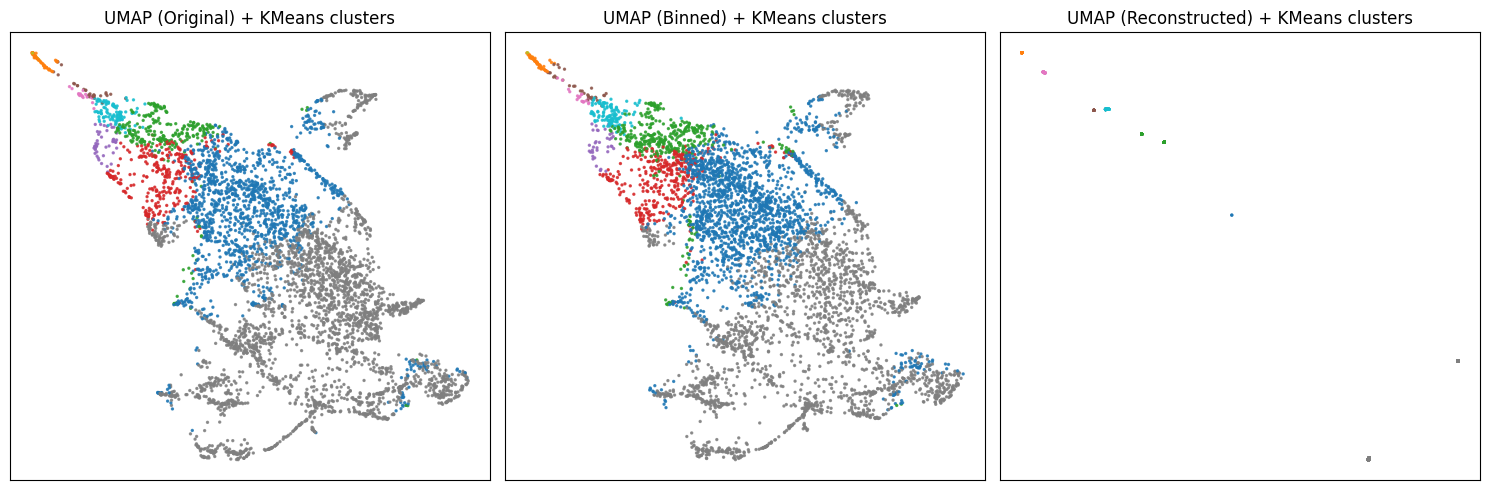

In [ ]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import numpy as np

import matplotlib.pyplot as plt

# Parameters
n_pcs = 50
n_clusters = 10
random_state = 42

# 1) PCA for dimensionality reduction (fit on original and reuse for others so components are comparable)
pca = PCA(n_components=n_pcs, random_state=random_state)
X_orig_pca = pca.fit_transform(top5k_genes)
X_binned_pca = pca.transform(binned_data)
X_recon_pca = pca.transform(recon_matrix)

# 2) UMAP embedding (fit on original PCA space, then transform the others)
reducer = reducer  # reuse existing reducer object (will be refit below)
reducer.set_params(n_components=2, random_state=random_state)
reducer.fit(X_orig_pca)
embedding_original = reducer.transform(X_orig_pca)
embedding_binned = reducer.transform(X_binned_pca)
embedding_reconstructed = reducer.transform(X_recon_pca)

# 3) Clustering (fit on original PCA space; predict on binned/recon to compare cluster assignments)
kmeans = KMeans(n_clusters=n_clusters, random_state=random_state)
kmeans.fit(X_orig_pca)
clusters_original = kmeans.labels_
clusters_binned = kmeans.predict(X_binned_pca)
clusters_reconstructed = kmeans.predict(X_recon_pca)

# 4) Quick cluster size prints
print("Original cluster sizes:", dict(zip(*np.unique(clusters_original, return_counts=True))))
print("Binned cluster sizes:", dict(zip(*np.unique(clusters_binned, return_counts=True))))
print("Reconstructed cluster sizes:", dict(zip(*np.unique(clusters_reconstructed, return_counts=True))))

# 5) Plot UMAPs colored by cluster (keeps embedding_* variables for downstream cells)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
sc0 = axes[0].scatter(embedding_original[:, 0], embedding_original[:, 1], c=clusters_original, s=2, cmap='tab10', alpha=0.8)
axes[0].set_title('UMAP (Original) + KMeans clusters')
sc1 = axes[1].scatter(embedding_binned[:, 0], embedding_binned[:, 1], c=clusters_binned, s=2, cmap='tab10', alpha=0.8)
axes[1].set_title('UMAP (Binned) + KMeans clusters')
sc2 = axes[2].scatter(embedding_reconstructed[:, 0], embedding_reconstructed[:, 1], c=clusters_reconstructed, s=2, cmap='tab10', alpha=0.8)
axes[2].set_title('UMAP (Reconstructed) + KMeans clusters')
for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()
plt.show()


Text(0.5, 1.0, 'UMAP of Reconstructed Data')

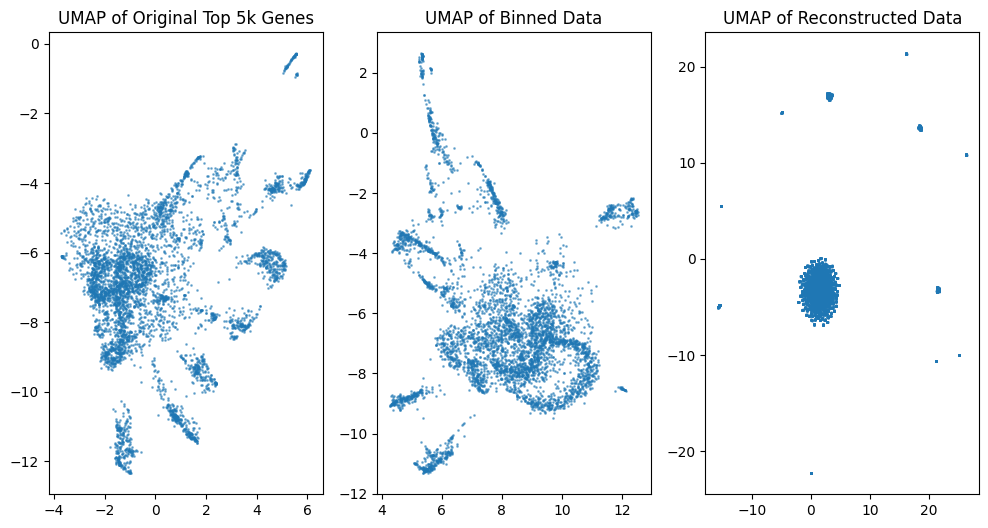

In [26]:
#Plot the UMAP embeddings
#Add the Binned data UMAP plot

plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1)
plt.scatter(embedding_original[:, 0], embedding_original[:, 1], s=1, alpha=0.5)
plt.title('UMAP of Original Top 5k Genes')
plt.subplot(1, 3, 2)
plt.scatter(embedding_binned[:, 0], embedding_binned[:, 1], s=1, alpha=0.5)
plt.title('UMAP of Binned Data')
plt.subplot(1, 3, 3)
plt.scatter(embedding_reconstructed[:, 0], embedding_reconstructed[:, 1], s=1, alpha=0.5)
plt.title('UMAP of Reconstructed Data') 
